# EDA: Bhutan Major Basin Discharge Data

**What you'll get:**
- Clean loading of each sheet (station) while skipping metadata rows
- Per‑station summary stats in tables
- Inline time‑series plots, histograms, and average monthly flow per station
- A combined monthly average plot across stations

## 1) Parameters

In [1]:
from pathlib import Path
import os, subprocess

def get_project_root(max_up=6):
    try:
        root = subprocess.check_output(["git", "rev-parse", "--show-toplevel"], text=True).strip()
        if root:
            return Path(root)
    except Exception:
        pass
    p = Path.cwd()
    for _ in range(max_up):
        if (p / "data").exists() and (p / "code").exists():
            return p
        if (p / ".git").exists():
            return p
        p = p.parent
    return Path.cwd()

PROJECT_ROOT = get_project_root()
print("Project root:", PROJECT_ROOT)


Project root: /Users/liuq13/bhutan_climate_modeling


In [2]:
# --- User parameters ---
INPUT_XLSX = "../../data/basin_discharge/Discharge data Major Basin.xlsx" 
SKIPROWS = 3                                               # metadata rows before header row (header at row 4)
print("Input:", INPUT_XLSX)


Input: ../../data/basin_discharge/Discharge data Major Basin.xlsx


## 2) Imports

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from pathlib import Path
import pandas as pd
import numpy as np
import re

%matplotlib inline
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 140)


In [4]:
OUT_DIR = PROJECT_ROOT / "data" / "basin_discharge" / "processed"
OUT_DIR.mkdir(parents=True, exist_ok=True)

# Model only these three stations; others will be skipped.
STATIONS_TO_KEEP = {
    # "StationNameExactlyAsSheet1",
    # "StationNameExactlyAsSheet2",
    # "StationNameExactlyAsSheet3",
}

## 3) Inspect workbook sheets

In [5]:
xls = pd.ExcelFile(INPUT_XLSX)
sheets = xls.sheet_names
sheets

['Lungtenphu (Wangchhu)',
 'Wangdi rapid (Punatshangchhu)',
 'Pangbang dangmechhu',
 'tingtibi (Mangdichhu)',
 'Kurjey (Chamkharchhu)']

## 4) Helper function to load and clean a station sheet

In [6]:
def load_station_sheet(xlsx_path: str, sheet_name: str, skiprows: int = 3):
    """
    Load one sheet (station) and do minimal cleaning:
      - Skip metadata rows (default: 3)
      - Trim column names; harmonize 'water Level' -> 'Water Level' if present
      - Parse 'Date' to datetime
      - Coerce 'Flow' and 'Water Level' to numeric
      - Drop entirely-empty columns
      - Sort by 'Date'
    """
    df = pd.read_excel(xlsx_path, sheet_name=sheet_name, skiprows=skiprows)
    df = df.dropna(axis=1, how="all")
    df.columns = [str(c).strip() for c in df.columns]
    if "water Level" in df.columns and "Water Level" not in df.columns:
        df = df.rename(columns={"water Level": "Water Level"})
    if "Date" not in df.columns:
        raise ValueError(f"'Date' column not found in sheet: {sheet_name}")
    df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
    for col in ["Flow", "Water Level"]:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")
    keep = [c for c in ["Date", "Flow", "Water Level"] if c in df.columns]
    df = df[keep].dropna(subset=["Date"]).sort_values("Date").reset_index(drop=True)
    return df


### Functions to process the station data

**Goal:** turn each station sheet into a clean **daily discharge** series with light QC flags, and write it to disk for modeling.

### Inputs (from your EDA loop)
- A DataFrame `df` for one station (read from the Excel sheet).
- The station’s name (sheet name).

### Processing (in `_canonicalize_station_df`)  
1. **Column detection**
   - Finds a **date/time** column by name (`date|datetime|time|timestamp`, case-insensitive).
   - Finds a **flow/discharge** column by name (`flow|discharge|flow_cms|discharge_cms`).  
     If not found but there’s exactly one numeric column, it uses that.

2. **Cast & sort**
   - `datetime_local = to_datetime(...)`
   - `discharge_cms = to_numeric(...)`
   - Drop rows with invalid datetimes; sort by time.

3. **Daily granularity**
   - Floor timestamps to **day** (`.dt.floor("D")`).
   - Remove **exact duplicate** (`datetime_local`, `discharge_cms`) pairs.
   - If multiple rows remain on the same day, **average** them → one value/day.

4. **QC flags** (values are **not** removed)
   - `qc_flag_negative`: `discharge_cms < 0`
   - `qc_flag_flatline`: ≥ **14 consecutive days** with identical values
   - `qc_flag_spike`: robust spike vs **31-day rolling median** using **MAD**  
     (flag if `|x − med| > 6 × 1.4826 × MAD`; if MAD==0, any deviation is a spike)
   - `qc_any` = OR of the above

5. **Schema & dtypes**
   - Columns:  
     `station_name, datetime_local, discharge_cms, qc_flag_negative, qc_flag_flatline, qc_flag_spike, qc_any`
   - `discharge_cms: float32`, QC flags: `bool`

6. **Metadata returned**
   - `first_day, last_day, n_days, n_duplicates_removed, mean, p50, p95`  
   - `pct_missing_in_span` is filled after knowing the full date span.

### Outputs written
- **Per-station daily parquet** → `data/basin_discharge/processed/station=<slug>.parquet`  
  (one row per day; Bhutan local time assumed; discharge only)
- **Catalog CSV** (after the loop) → `data/basin_discharge/processed/stations_catalog.csv`  
  with per-station summary + relative parquet path.

### Assumptions
- Discharge is the modeling target (water level/stage is ignored).
- Timestamps are **Bhutan local wall-clock** (no timezone conversion).
- Units are **m³/s (cms)**.

### Knobs you can tune
- Flatline run length: **14** days → change if needed.
- Spike window/threshold: **31 days**, **6× MAD** → adjust sensitivity.
- Within-day aggregator: **mean** (change to `sum` only if your input is a daily volume).

In [7]:
def _slugify(name: str) -> str:
    s = re.sub(r"\s+", "_", name.strip())
    s = re.sub(r"[^A-Za-z0-9_]+", "", s)
    return s.lower()

def _canonicalize_station_df(df_raw: pd.DataFrame, station_name: str) -> tuple[pd.DataFrame, dict]:
    """
    Standardize a station table to daily:
      - detect date & flow columns
      - to_datetime → floor to day
      - drop exact duplicate timestamps, average if multiple rows per day remain
      - add light QC flags
      - return tidy df + small metadata dict
    """
    cols = {c.lower(): c for c in df_raw.columns}

    # date-like column
    date_col = next((cols[k] for k in ["date", "datetime", "time", "timestamp"] if k in cols), None)
    if date_col is None:
        raise ValueError(f"{station_name}: no date/datetime column found")

    # flow-like column
    flow_col = next((cols[k] for k in ["flow", "discharge", "flow_cms", "discharge_cms"] if k in cols), None)
    if flow_col is None:
        # fallback: if exactly one numeric col, use it
        num_cols = [c for c in df_raw.columns if pd.api.types.is_numeric_dtype(df_raw[c])]
        if len(num_cols) == 1:
            flow_col = num_cols[0]
        else:
            raise ValueError(f"{station_name}: cannot identify discharge column")

    df = pd.DataFrame({
        "station_name": station_name,
        "datetime_local": pd.to_datetime(df_raw[date_col], errors="coerce"),
        "discharge_cms": pd.to_numeric(df_raw[flow_col], errors="coerce"),
    }).dropna(subset=["datetime_local"]).sort_values("datetime_local")

    # daily granularity
    df["datetime_local"] = df["datetime_local"].dt.floor("D")

    # remove exact duplicates, then average if multi-per-day
    before = len(df)
    df = df.drop_duplicates(subset=["datetime_local", "discharge_cms"])
    dup_removed_exact = before - len(df)

    df = (df.groupby(["station_name", "datetime_local"], as_index=False)
            .agg({"discharge_cms": "mean"}))

    # --- QC flags ---
    neg = (df["discharge_cms"] < 0)

    # flatline (≥14-day identical runs)
    v = df["discharge_cms"].values
    flat = np.zeros(len(v), dtype=bool)
    if len(v):
        start = 0
        for i in range(1, len(v)+1):
            end = i
            if i == len(v) or not (pd.notna(v[i]) and pd.notna(v[i-1]) and v[i] == v[i-1]):
                if end - start >= 14 and np.all(pd.notna(v[start:end])):
                    flat[start:end] = True
                start = i

    # spikes vs rolling median (31d) using MAD
    med = df["discharge_cms"].rolling(31, min_periods=10).median()
    abs_dev = (df["discharge_cms"] - med).abs()
    mad = abs_dev.rolling(31, min_periods=10).median()
    sigma = 1.4826 * mad
    spike = abs_dev > (6.0 * sigma)
    spike = spike | ((sigma == 0) & (abs_dev > 0))

    df["qc_flag_negative"] = neg.fillna(False)
    df["qc_flag_flatline"] = flat
    df["qc_flag_spike"]    = spike.fillna(False)
    df["qc_any"]           = (df["qc_flag_negative"] | df["qc_flag_flatline"] | df["qc_flag_spike"])

    # tidy dtypes
    df["discharge_cms"] = df["discharge_cms"].astype("float32")
    for c in ["qc_flag_negative","qc_flag_flatline","qc_flag_spike","qc_any"]:
        df[c] = df[c].astype(bool)

    meta = {
        "station_name": station_name,
        "first_day": df["datetime_local"].min(),
        "last_day":  df["datetime_local"].max(),
        "n_days":    int(df["datetime_local"].nunique()),
        "n_duplicates_removed": int(dup_removed_exact),
        "pct_missing_in_span": None,  # filled after we know span length
        "mean": float(df["discharge_cms"].mean(skipna=True)) if len(df) else np.nan,
        "p50":  float(df["discharge_cms"].quantile(0.5)) if len(df) else np.nan,
        "p95":  float(df["discharge_cms"].quantile(0.95)) if len(df) else np.nan,
    }
    return df, meta

def _save_station_parquet(df_station: pd.DataFrame, station_name: str) -> Path:
    path = OUT_DIR / f"station={_slugify(station_name)}.parquet"
    df_station.to_parquet(path, index=False)
    return path


## 5) Utility: compute per‑station summary statistics

In [8]:
def station_summary(df: pd.DataFrame) -> dict:
    out = {}
    out["Start Date"] = df["Date"].min().date() if len(df) else None
    out["End Date"] = df["Date"].max().date() if len(df) else None
    out["N Obs"] = int(len(df))
    if "Flow" in df.columns:
        flow = df["Flow"]
        out["Mean Flow"] = float(flow.mean())
        out["Median Flow"] = float(flow.median())
        out["Min Flow"] = float(flow.min())
        out["Max Flow"] = float(flow.max())
        out["Std Flow"] = float(flow.std())
        out["Missing Flow"] = int(flow.isna().sum())
    else:
        out["Mean Flow"] = out["Median Flow"] = out["Min Flow"] = out["Max Flow"] = out["Std Flow"] = None
        out["Missing Flow"] = None
    if "Water Level" in df.columns:
        wl = df["Water Level"]
        out["Missing Water Level"] = int(wl.isna().sum())
        if "Flow" in df.columns:
            corr = pd.concat([df["Flow"], wl], axis=1).dropna().corr().iloc[0, 1]
            out["Flow–WL Corr"] = float(corr)
        else:
            out["Flow–WL Corr"] = None
    else:
        out["Missing Water Level"] = None
        out["Flow–WL Corr"] = None
    return out


## 6) Plot functions (inline display only)

In [9]:
def show_timeseries(df: pd.DataFrame, station: str):
    if "Flow" not in df.columns:
        return
    plt.figure(figsize=(12, 4))
    plt.plot(df["Date"], df["Flow"])  # single chart; no colors/styles
    plt.xlabel("Date"); plt.ylabel("Flow (m³/s)")
    plt.title(f"{station} — Daily Flow Time Series")
    plt.tight_layout(); plt.show()

def show_histogram(df: pd.DataFrame, station: str):
    if "Flow" not in df.columns:
        return
    vals = df["Flow"].dropna().values
    if len(vals) > 1:
        import numpy as np
        q25, q75 = np.percentile(vals, [25, 75])
        iqr = q75 - q25
        bin_width = 2 * iqr * (len(vals) ** (-1/3)) if iqr > 0 else 0
        bins = int(np.ceil((vals.max() - vals.min()) / bin_width)) if bin_width > 0 else 50
        bins = max(bins, 10)
    else:
        bins = 10
    plt.figure(figsize=(6, 4))
    plt.hist(vals, bins=bins)
    plt.xlabel("Flow (m³/s)"); plt.ylabel("Frequency")
    plt.title(f"{station} — Flow Distribution")
    plt.tight_layout(); plt.show()

def compute_monthly_means(df: pd.DataFrame, station: str):
    if "Flow" not in df.columns:
        return pd.DataFrame()
    tmp = df.dropna(subset=["Flow"]).copy()
    tmp["Month"] = tmp["Date"].dt.month
    monthly = tmp.groupby("Month", as_index=False)["Flow"].mean()
    plt.figure(figsize=(8, 4))
    plt.plot(monthly["Month"], monthly["Flow"], marker="o")
    plt.xlabel("Month"); plt.ylabel("Avg Flow (m³/s)")
    plt.title(f"{station} — Average Monthly Flow")
    plt.xticks(range(1, 13))
    plt.tight_layout(); plt.show()
    return monthly


## 7) Load all stations, show summaries & inline plots

[SAVED] Lungtenphu (Wangchhu) → /Users/liuq13/bhutan_climate_modeling/data/basin_discharge/processed/station=lungtenphu_wangchhu.parquet


,Station,Start Date,End Date,N Obs,Mean Flow,Median Flow,Min Flow,Max Flow,Std Flow,Missing Flow,Missing Water Level,Flow–WL Corr
0,Lungtenphu (Wangchhu),1991-04-22,2024-12-31,12308,21.874529,10.441,2.846,661.132,23.527615,0,66,0.7908


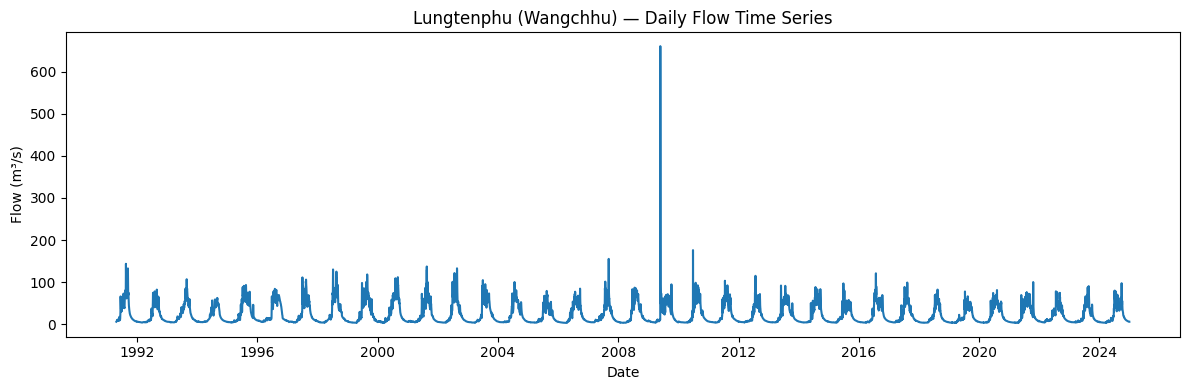

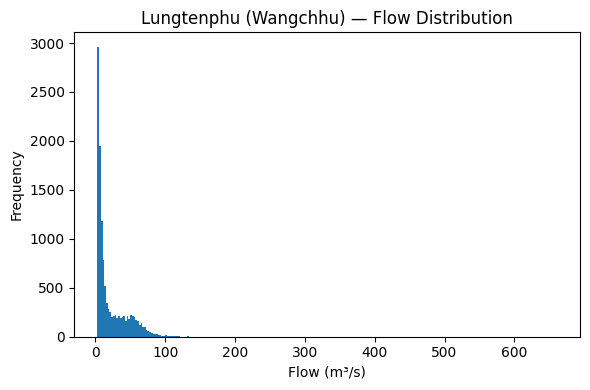

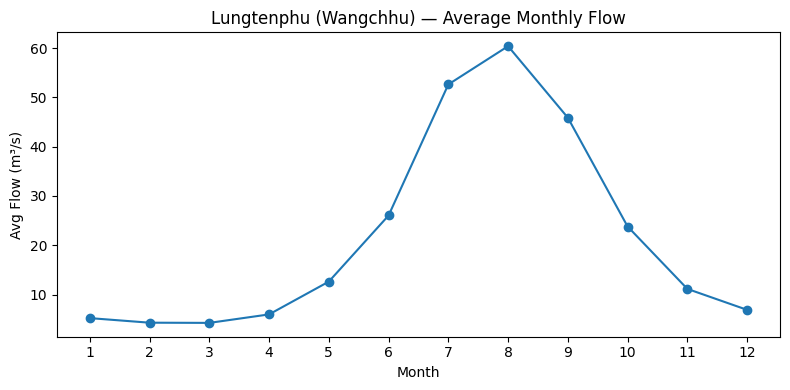

[SAVED] Wangdi rapid (Punatshangchhu) → /Users/liuq13/bhutan_climate_modeling/data/basin_discharge/processed/station=wangdi_rapid_punatshangchhu.parquet


,Station,Start Date,End Date,N Obs,Mean Flow,Median Flow,Min Flow,Max Flow,Std Flow,Missing Flow,Missing Water Level,Flow–WL Corr
0,Wangdi rapid (Punatshangchhu),2000-01-01,2023-12-31,8766,298.200705,162.571,51.713,2650.26,279.563571,42,1,0.967266


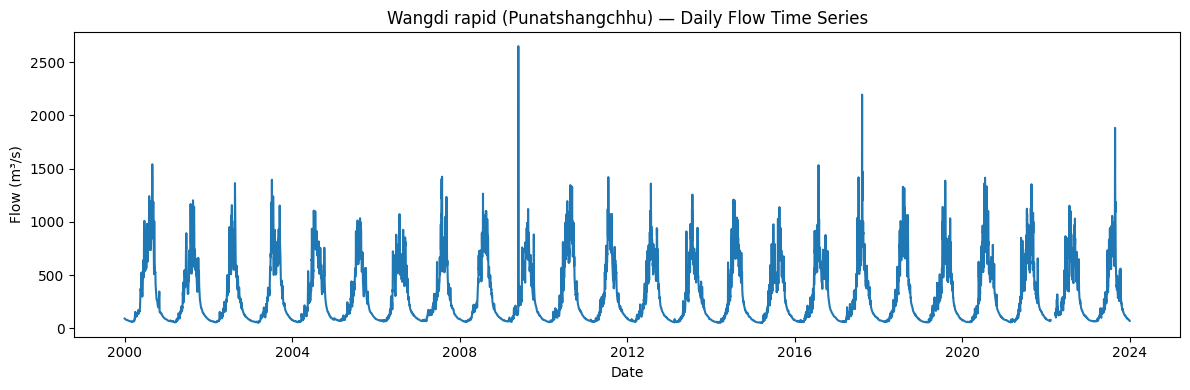

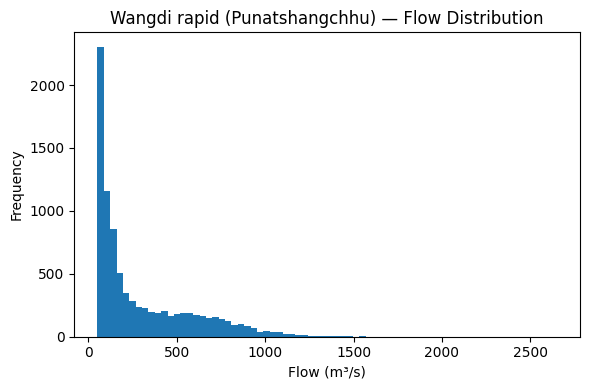

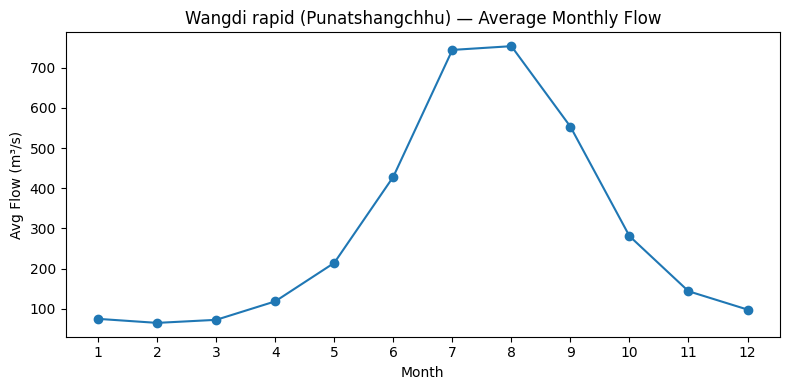

[SAVED] Pangbang dangmechhu → /Users/liuq13/bhutan_climate_modeling/data/basin_discharge/processed/station=pangbang_dangmechhu.parquet


,Station,Start Date,End Date,N Obs,Mean Flow,Median Flow,Min Flow,Max Flow,Std Flow,Missing Flow,Missing Water Level,Flow–WL Corr
0,Pangbang dangmechhu,2011-01-01,2023-12-31,4748,781.430324,416.2985,119.147,7131.638,822.571684,0,0,0.952314


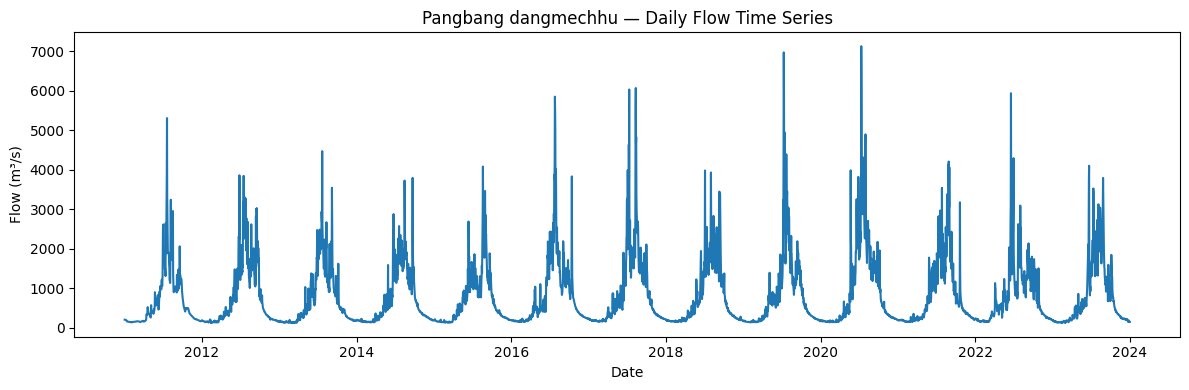

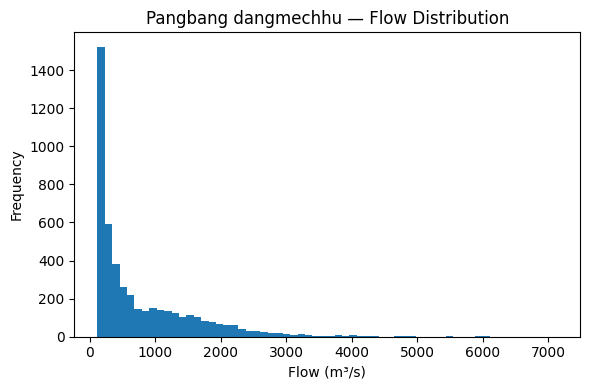

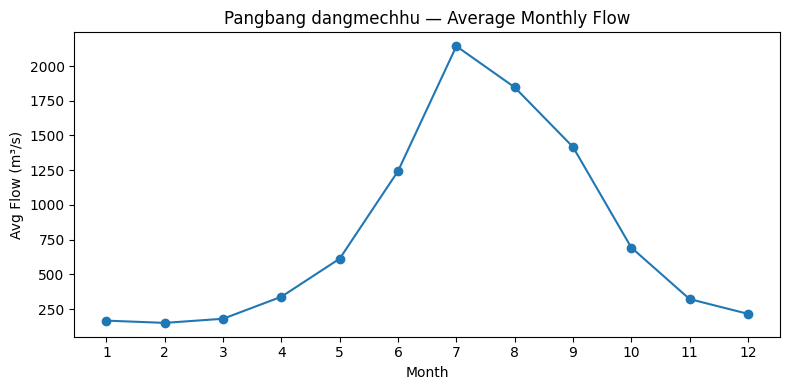

[SAVED] tingtibi (Mangdichhu) → /Users/liuq13/bhutan_climate_modeling/data/basin_discharge/processed/station=tingtibi_mangdichhu.parquet


,Station,Start Date,End Date,N Obs,Mean Flow,Median Flow,Min Flow,Max Flow,Std Flow,Missing Flow,Missing Water Level,Flow–WL Corr
0,tingtibi (Mangdichhu),2005-06-26,2023-12-31,6763,136.893623,79.508,23.45,2173.866,124.542809,6,371,0.843014


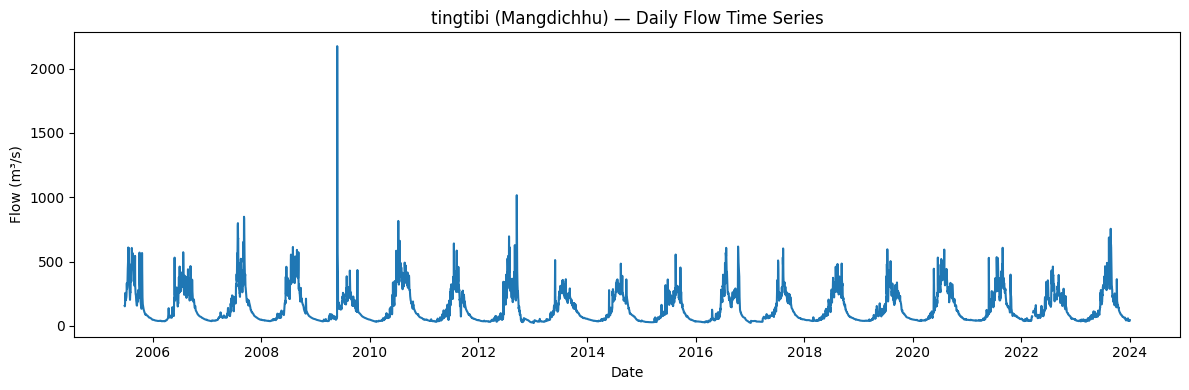

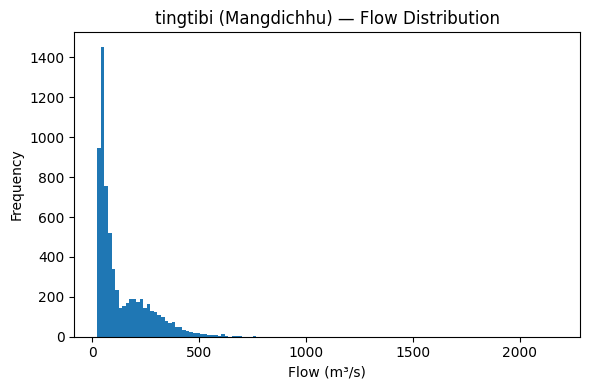

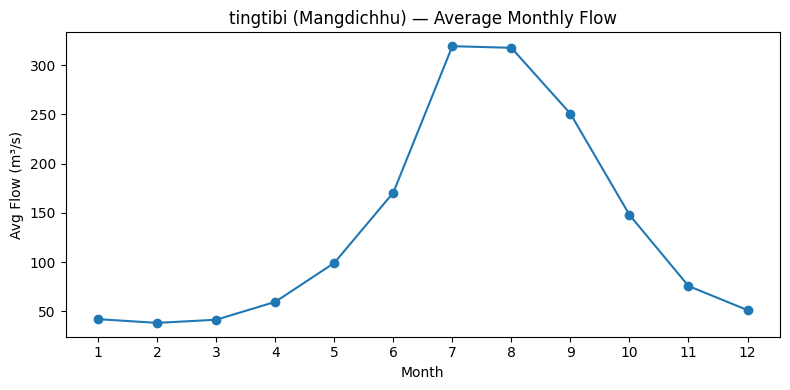

[SAVED] Kurjey (Chamkharchhu) → /Users/liuq13/bhutan_climate_modeling/data/basin_discharge/processed/station=kurjey_chamkharchhu.parquet


,Station,Start Date,End Date,N Obs,Mean Flow,Median Flow,Min Flow,Max Flow,Std Flow,Missing Flow,Missing Water Level,Flow–WL Corr
0,Kurjey (Chamkharchhu),2000-01-01,2023-12-31,8766,52.351836,30.61,9.431,586.056,48.062139,0,9,0.856908


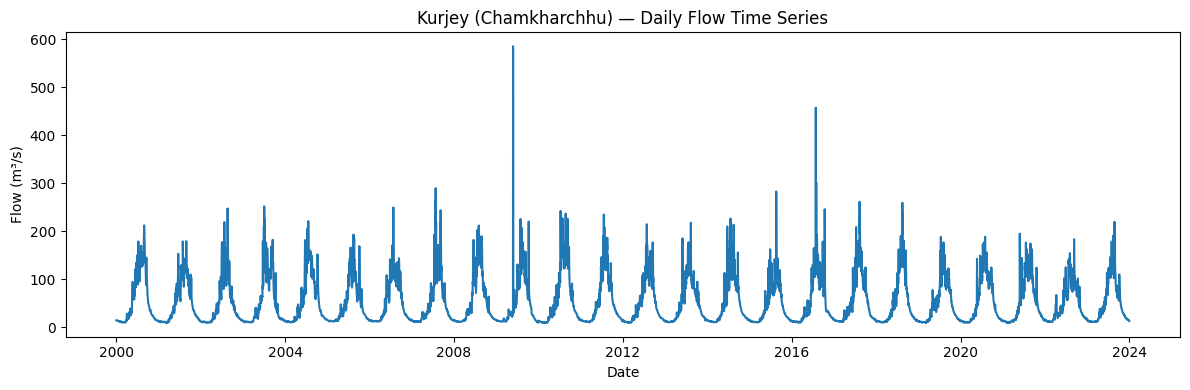

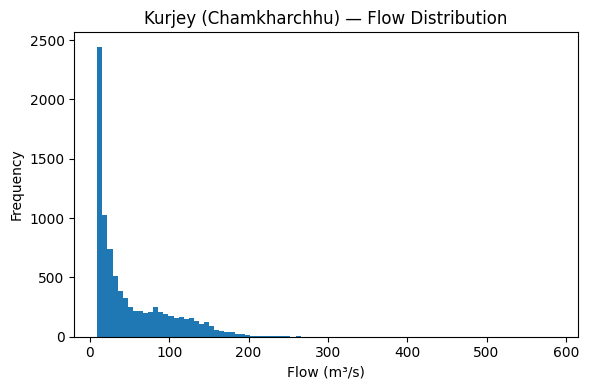

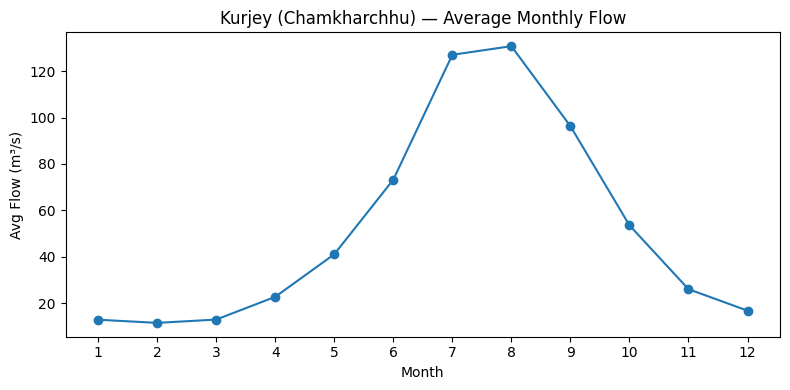

In [10]:
all_summaries = []
all_catalog = []
monthly_tables = {}

for sheet in sheets:
    station = sheet
    try:
        df = load_station_sheet(INPUT_XLSX, sheet_name=sheet, skiprows=SKIPROWS)
    except Exception as e:
        print(f"[WARN] Skipping '{sheet}': {e}")
        continue

    # Standardize, QC, and save per-station parquet
    df_clean, meta = _canonicalize_station_df(df, station)

    # compute missing % in span
    if pd.notna(meta["first_day"]) and pd.notna(meta["last_day"]):
        span_len = len(pd.date_range(meta["first_day"], meta["last_day"], freq="D"))
        meta["pct_missing_in_span"] = round(100.0 * (1 - df_clean["datetime_local"].nunique() / span_len), 2) if span_len > 0 else 0.0
    else:
        meta["pct_missing_in_span"] = None

    p = _save_station_parquet(df_clean, station)
    print(f"[SAVED] {station} → {p}")

    # Keep a small catalog row
    catalog_row = {
        "station_name": meta["station_name"],
        "first_day":    meta["first_day"],
        "last_day":     meta["last_day"],
        "n_days":       meta["n_days"],
        "n_duplicates_removed": meta["n_duplicates_removed"],
        "pct_missing_in_span":  meta["pct_missing_in_span"],
        "mean": meta["mean"], "p50": meta["p50"], "p95": meta["p95"],
        "parquet_path": str(p.relative_to(PROJECT_ROOT))
    }
    # Initialize outside the loop: all_catalog = []
    all_catalog.append(catalog_row)
    
    # Summary table row
    summ = station_summary(df)
    row = {"Station": station, **summ}
    all_summaries.append(row)

    # Inline visuals
    display(pd.DataFrame([row]))
    show_timeseries(df, station)
    show_histogram(df, station)
    monthly_tables[station] = compute_monthly_means(df, station)


In [11]:
catalog_df = pd.DataFrame(all_catalog).sort_values("station_name")
catalog_path = OUT_DIR / "stations_catalog.csv"
catalog_df.to_csv(catalog_path, index=False)
catalog_path, catalog_df.head()


(PosixPath('/Users/liuq13/bhutan_climate_modeling/data/basin_discharge/processed/stations_catalog.csv'),
                     station_name  first_day   last_day  n_days  n_duplicates_removed  pct_missing_in_span        mean         p50  \
 4          Kurjey (Chamkharchhu) 2000-01-01 2023-12-31    8766                     0                  0.0   52.351833   30.610001   
 0          Lungtenphu (Wangchhu) 1991-04-22 2024-12-31   12308                     0                  0.0   21.874527   10.441000   
 2            Pangbang dangmechhu 2011-01-01 2023-12-31    4748                     0                  0.0  781.430298  416.298492   
 1  Wangdi rapid (Punatshangchhu) 2000-01-01 2023-12-31    8766                     0                  0.0  298.200714  162.570999   
 3          tingtibi (Mangdichhu) 2005-06-26 2023-12-31    6763                     0                  0.0  136.893631   79.508003   
 
            p95                                       parquet_path  
 4   148.176754  dat

## 8) Combined monthly average flow across stations (inline)

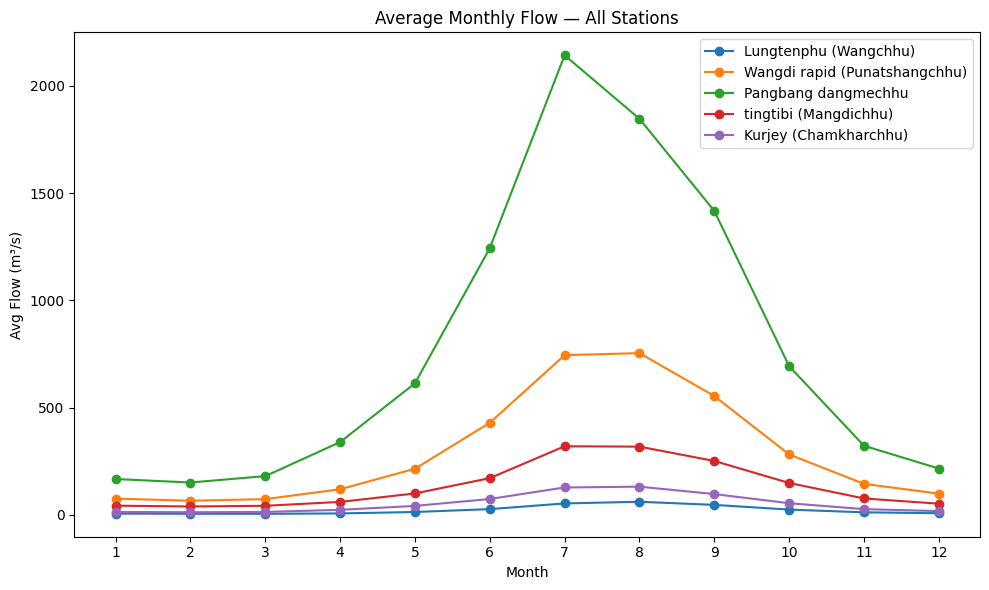

In [12]:
plt.figure(figsize=(10, 6))
for station, mdf in monthly_tables.items():
    if mdf is None or mdf.empty:
        continue
    plt.plot(mdf["Month"], mdf["Flow"], marker="o", label=station)
plt.xlabel("Month"); plt.ylabel("Avg Flow (m³/s)")
plt.title("Average Monthly Flow — All Stations")
plt.xticks(range(1, 13))
plt.legend(); plt.tight_layout(); plt.show()
